<a href="https://colab.research.google.com/github/williamryanmckee-nwa/Deep-Learning/blob/main/9_04_Implementation_of_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## __Transfer Learning__
- Transfer learning refers to a technique in machine learning where a pre-trained model, typically trained on a large dataset, is used as a starting point for solving a different but related task.
- It involves using models that were trained on one problem as a starting point for solving a related problem.
- It is flexible, allowing the use of pre-trained models directly, as feature extraction preprocessing, and integrated into entirely new models.



In this demo, we will learn how to utilize transfer learning with the VGG16 model to adapt pre-trained features for a new classification task, highlighting efficient model adaptation without extensive new training.

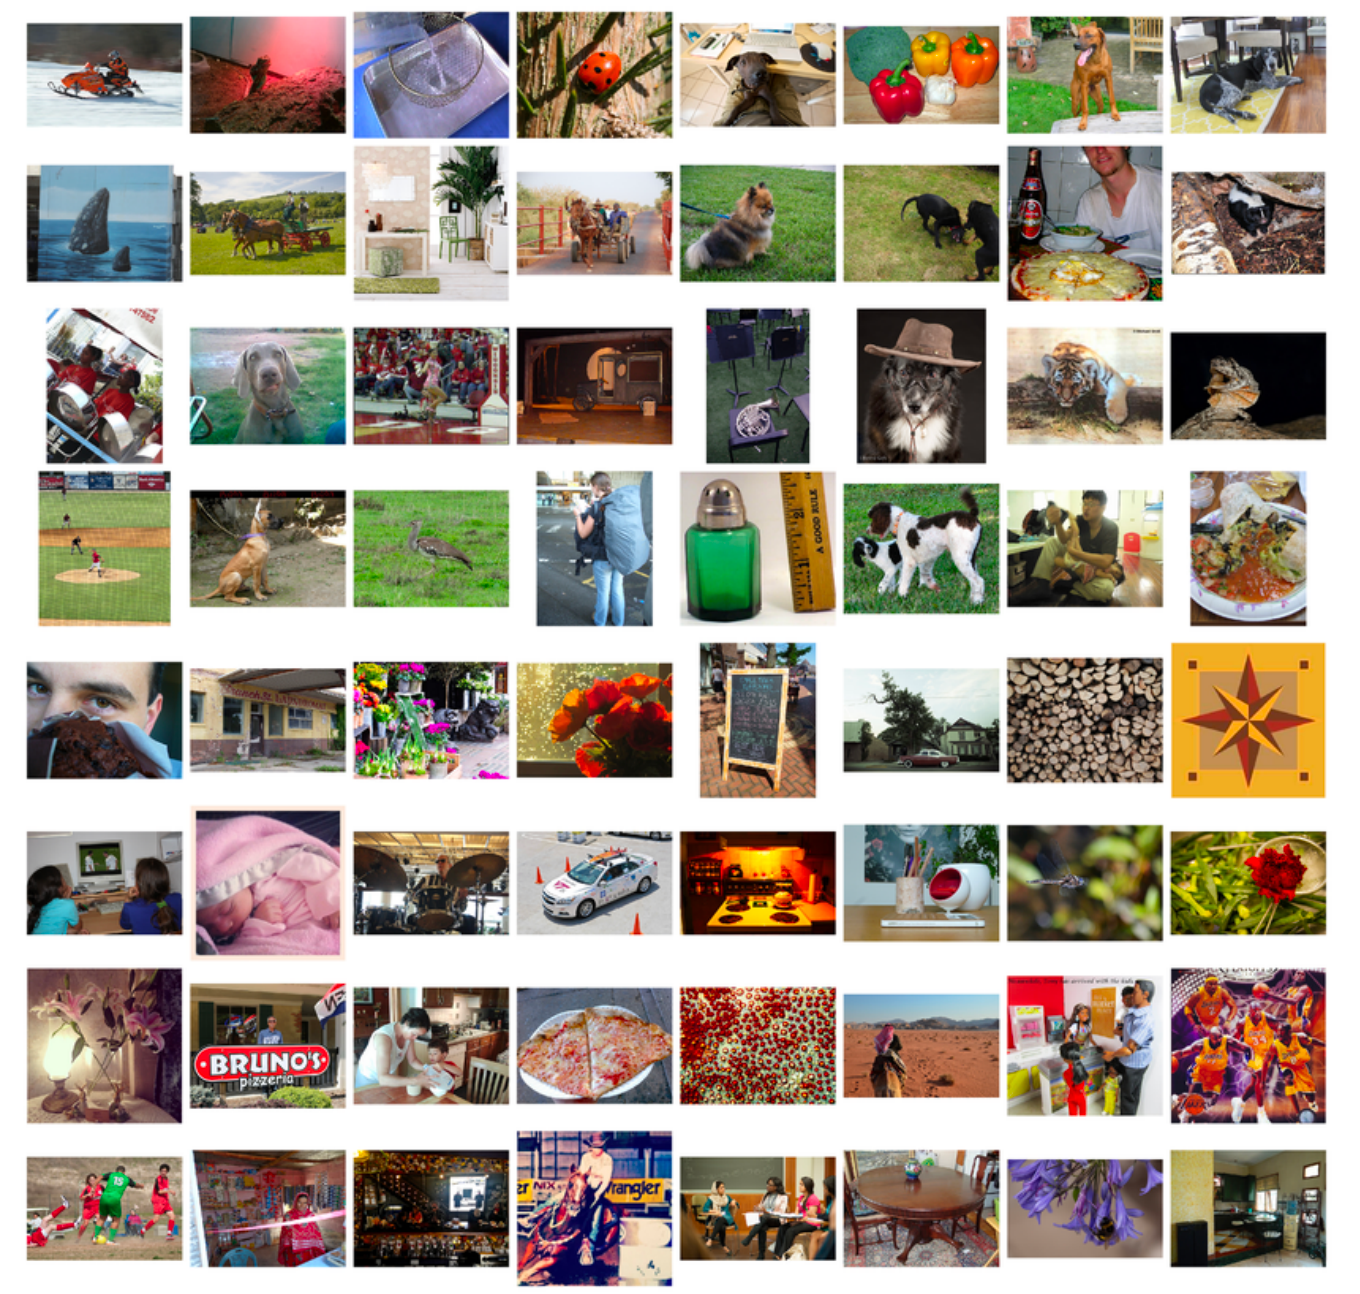

## Steps to be followed:
1. Import the required libraries
2. Add classifier layers
3. Perform preprocessing and feature extraction

### Step 1: Import the required libraries

- The **from tensorflow.keras.utils import load_img** loads an image file from the file system.

- The **from tensorflow.keras.utils import img_to_array** converts an image loaded with load_img into a NumPy array.

- The **from keras.applications.vgg16 import preprocess_input** preprocesses the input image array before feeding it to the VGG16 model. VGG16 expects the input images to be preprocessed in a specific way.

- The **from keras.applications.vgg16 import VGG16** imports the VGG16 model architecture. VGG16 is a popular convolutional neural network model pre-trained on the ImageNet dataset for image classification.

In [1]:
!pip install tensorflow==2.20.0 scikeras==0.13.0 keras==3.13.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.0 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2


In [2]:
import os

# Disable oneDNN optimizations to avoid potential minor numerical differences caused by floating-point round-off errors.
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

In [3]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
# Set CUDA_VISIBLE_DEVICES:
#   "-1" -> force CPU-only execution
#   "0"  -> use first GPU (change to "1", "2", etc. for other GPUs)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"


In [4]:
#This is a Keras utility to load an image file into Python for preprocessing or deep learning model such as VGG16.
from tensorflow.keras.utils import load_img
#from keras.utils import load_img

#This is to convert a Keras/PIL image into a Numpy array
from tensorflow.keras.utils import img_to_array
#from keras.utils import img_to_array

#This requires the inage to be in a format expected by ImageNet trained model.
from keras.applications.vgg16 import preprocess_input

#Keras is the API, applications is the pre-trained models, vgg16 is the module containing VGG16, VGG is the actual model.
from keras.applications.vgg16 import VGG16


/usr/local/lib/python3.13/dist-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


### Step 2: Add classifier layers
- It demonstrates how to load a pre-trained VGG16 model without its classifier layers and then add new custom classifier layers on top of it.
- The new model is defined by connecting the output of the pre-trained VGG16 model to a flattening layer. It is followed by a dense layer with 1024 units and ReLU activation and a dense layer with 10 units and Softmax activation for multi-class classification.
- The model summary provides an overview of the architecture and layer configurations.

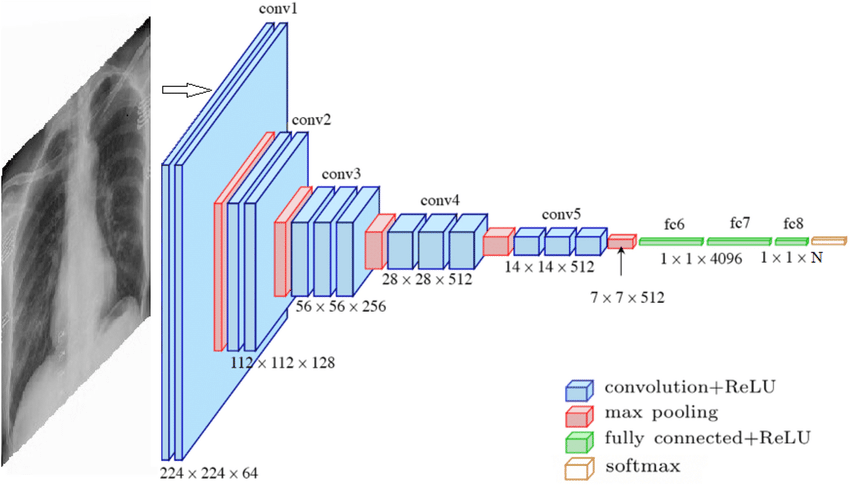

In [5]:
#Model is the Keras class used to create Neural Network by connecting Inputs to Outputs.
from keras.models import Model

#This is a fully connected network layer.
from keras.layers import Dense

#Converts a multi dimensional feature map to a one dimensional feature vector.
from keras.layers import Flatten

#include_top, removes VGG16's original ImageNet classification layers.
#input_shape, height, width, RGB
base_model = VGG16(include_top=False, input_shape=(300, 300, 3))

#base_model-your VGG model, .layers-all the layers, [-1] - the last layer, .output - output produced by the last layer.
flat1 = Flatten()(base_model.layers[-1].output)
#Flatten()(base_model.output). Create the layer and apply the data to the layer.

#Your first hidden layer.
#flat1 stores the output of the flatten layer.
class1 = Dense(1024, activation='relu')(flat1)

#Your output layer.
#Softmax converts the raw output from the final layer and convert them into probabilities that adds up to 1.
output = Dense(10, activation='softmax')(class1)

#The Start and End of the model.
model = Model(inputs=base_model.inputs, outputs=output)

#This is the architecture of the model.
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 300, 300, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 300, 300, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 150, 150, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 150, 150, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 150, 150, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 75, 75, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 75, 75, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 75, 75, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 75, 75, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 37, 37, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 37, 37, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 37, 37, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 37, 37, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 18, 18, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    42,468,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,193,290 (218.18 MB)

 Trainable params: 57,193,290 (218.18 MB)

 Non-trainable params: 0 (0.00 B)

**Observation**
- Running the example means that the new model is ready for training and summarizes the model architecture.
- The output of the last pooling layer is flattened, and the new fully connected layers are added.
- The weights of the VGG16 model and the new model will all be trained together on the new dataset.

### Step 3: Perform preprocessing and feature extraction
- The image is loaded from a file and preprocessed to meet the input requirements of the VGG16 model (resizing, converting to a numpy array, and reshaping).

- The modified model predicts and extracts features from the input image, resulting in a feature vector with a specific shape.

In [6]:
#height-300, width-300, RGB
image = load_img('dog.jpg', target_size=(300, 300))

#Question : What is the pixel count vs the number of values?

#Convert the pixels(image object) to numbers.
image = img_to_array(image)

#I am sending 1 image and these are the dimensions.
image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))

#Convert from RGB to BGR
#Subtract the mean pixel value from the channels
#Expected by the VGG16 pre trained model.
image = preprocess_input(image)


# Predict using the correct model
features = model.predict(image)
print("Output shape:", features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
Output shape: (1, 10)


**Observation**

- The VGG16 model weights are downloaded and loaded successfully, and the extracted features from the input image have a shape of (1, 10).
- The final layer in the model is a Dense layer with 10 units and a softmax activation function. This is designed to output the probabilities of each of the 10 classes for the input image. Since you have one image as input, the batch size is 1, leading to the output shape of (1, 10).